In [1]:
import pandas as pd       
import numpy as np            
import matplotlib.pyplot as plt 
import seaborn as sns         
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_blobs

%matplotlib inline

# Geometric Customer Segmentation using K-Means Clustering

### Mathematical Analysis and Business Applicaion

The goal of this project is to apply geometric principles to identify distinct customer groups based on their spending behavior and income. By using vector space modeling, we aim to provide actionable insights for business strategy

## 1. Data Generation and Simulation
To build a robust model, we start by simulating customer data that represents two key metrics: **Annual Income** and **Spending Score**. 

We use the `make_blobs` function from `sklearn`, which is ideal for clustering tasks because it creates distinct "blobs" or groups of points in a 2D plane.This allows us to test our mathematical intuitions on a dataset with a known "ground truth".

### Mathematical Parameters:
* **n_samples (300)**: Represents our unique customer profiles.
* **centers (3)**: Defines the number of initial segments or clusters we expect to find.
* **cluster_std (0.60)**: Controls the "tightness" of each cluster, representing how similar customers within a group are to each other.
* **random_state (42)**: A fixed seed ensures **reproducibility**, meaning the results will be identical every time the code is executed.

In [2]:
n_customers = 300
n_segments = 3
random_seed = 42 

X, y_true = make_blobs(
    n_samples=n_customers, 
    centers=n_segments, 
    cluster_std=0.60, 
    random_state=random_seed
)

df_simulated = pd.DataFrame(X, columns=['Annual_Income', 'Spending_Score'])

print(f"Successfully generated a dataset with {n_customers} unique customer profiles.")
print(df_simulated.head()) 

Successfully generated a dataset with 300 unique customer profiles.
   Annual_Income  Spending_Score
0      -7.155244       -7.390016
1      -7.395875       -7.110843
2      -2.015671        8.281780
3       4.509270        2.632436
4      -8.102502       -7.484961


The coordinates are generated using a Gaussian distribution around fixed centers. This represents the natural variance in customer behavior within a specific segment.

### Data Transformation: From Mathematical Coordinates to Business Metrics

### The Challenge with Raw Synthetic Data
Initially, our data generated by `make_blobs` resulted in abstract coordinates (e.g., negative values and arbitrary scales). While mathematically sound for clustering, these do not represent realistic business metrics like **Annual Income** or **Spending Score**.

### Mathematical Translation (Scaling)
To ensure that the translation between the "real-world" problem and its mathematical counterpart is correct, we apply **Feature Scaling**. 

**Why Scaling is Crucial:**
1. **Interpretation**: It maps abstract points to a logical range (e.g., 0-100 for spending index).
2. **Algorithm Performance**: Distance-based algorithms like K-Means are sensitive to the scale of features. If one axis has much larger values than the other, it will dominate the distance calculation.

### Implementation:
We use the `MinMaxScaler` to transform our features into a human-readable format:
* **Annual Income**: Scaled to represent a range from approximately $15k to $120k.
* **Spending Score**: Scaled to a standard 1-100 index.

In [3]:
scaler = MinMaxScaler(feature_range=(0, 100))

df_simulated[['Annual_Income', 'Spending_Score']] = scaler.fit_transform(
    df_simulated[['Annual_Income', 'Spending_Score']]
)

df_simulated['Annual_Income'] = df_simulated['Annual_Income'] * 1.05 + 15

print("Scaled Data Preview:")
print(df_simulated.head())

Scaled Data Preview:
   Annual_Income  Spending_Score
0      23.809070        4.607903
1      22.053404        6.084412
2      61.307811       87.493910
3     108.914307       57.615294
4      16.897798        4.105750


## 2. Exploratory Data Analysis (EDA)
Before applying any clustering algorithm, we must visualize the spatial distribution of our customers. This step helps us build an intuition about the natural groupings in the data.

**Key Goals:**
* Confirm if the clusters are visually separable.
* Identify any potential outliers or overlaps.
* Validate that our synthetic data aligns with our mathematical assumptions.

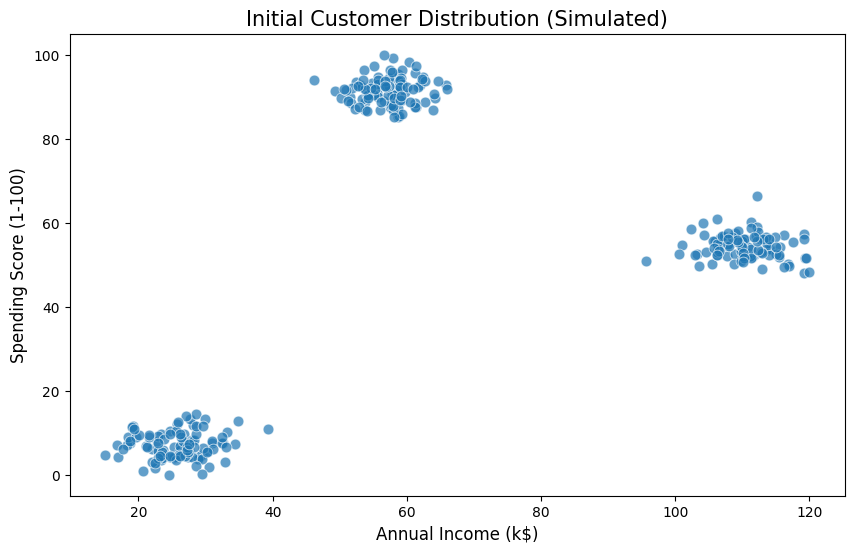

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual_Income', 
    y='Spending_Score', 
    data=df_simulated, 
    s=60, 
    alpha=0.7, 
    edgecolor='w'
)

plt.title('Initial Customer Distribution (Simulated)', fontsize=15)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.show()

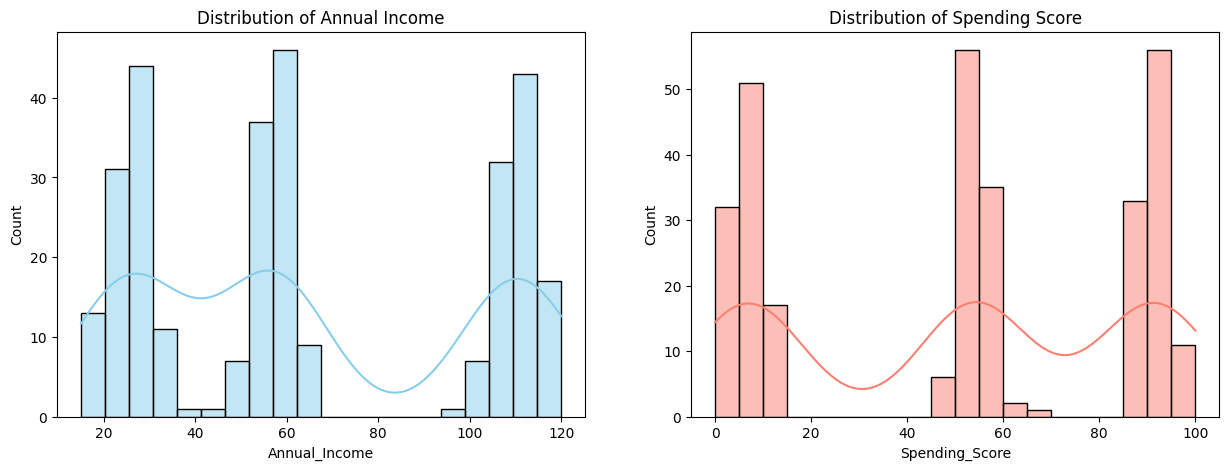

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_simulated['Annual_Income'], bins=20, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribution of Annual Income')

sns.histplot(df_simulated['Spending_Score'], bins=20, kde=True, ax=ax2, color='salmon')
ax2.set_title('Distribution of Spending Score')

plt.show()

### Observations from EDA
The scatter plot clearly shows three distinct "islands" of data points, which matches our initial `n_segments=3` parameter. 
- The **Annual Income** follows a multi-modal distribution, suggesting different wealth tiers.
- The **Spending Score** shows similar clustering, which will be the basis for our geometric distance calculations.

## 3. Mathematical Theory of K-Means Clustering

The K-Means algorithm is an iterative optimization process that aims to partition $n$ observations into $k$ clusters. 

### A. Euclidean Distance
To determine which cluster a customer (point) belongs to, we calculate the distance between a point $P$ and a cluster center (centroid) $C$. In our 2D feature space, for a point $P(x, y)$ and centroid $C(x_c, y_c)$, the **Euclidean distance** is defined as:

$$d(P, C) = \sqrt{(x - x_c)^2 + (y - y_c)^2}$$

The algorithm assigns each point to the centroid that minimizes this distance.

### B. Centroid Update (The Optimization Step)
After all points are assigned to a cluster, the algorithm updates the centroid position to be the mean (average) of all points currently assigned to that cluster. If a cluster $S_j$ contains $m$ points, the new centroid $C_j$ is calculated as:

$$C_j = \frac{1}{m} \sum_{P \in S_j} P$$

### C. Objective Function (WCSS)
The goal of the algorithm is to minimize the **Within-Cluster Sum of Squares (WCSS)**:

$$J = \sum_{j=1}^{k} \sum_{P \in S_j} ||P - C_j||^2$$

This objective function represents the total "geometric cost" of our segmentation. Our task is to reach a state where $J$ cannot be reduced further.

### 4. Data Preprocessing: Feature Scaling
Before applying the K-Means algorithm, we must ensure that all features contribute equally to the distance calculations. Since K-Means relies on **Euclidean Distance**, variables with larger numerical ranges (like Annual Income) would disproportionately influence the model compared to smaller ones (like Spending Score).

We use **MinMaxScaler** to transform our features into a uniform range of $[0, 1]$. This normalization is critical for geometric-based algorithms to function correctly.

In [6]:
scaler = MinMaxScaler()

columns_to_scale = ['Annual_Income', 'Spending_Score']

X_scaled = scaler.fit_transform(df_simulated[columns_to_scale])

print("Succsesfully scaled. Format ofX_scaled:", X_scaled.shape)

Succsesfully scaled. Format ofX_scaled: (300, 2)


### 5. Algorithmic Implementation (K-Means)
Now that our data is scaled, we initialize the **K-Means++** algorithm. 
* **n_clusters=3**: We set this to 3, matching our synthetic data generation.
* **init='k-means++'**: This ensures a smarter initialization of centroids, speeding up convergence and avoiding local optima.

The model will iteratively move the centroids until the **Within-Cluster Sum of Squares (WCSS)** is minimized, effectively finding the "geographic center" of each customer segment.

In [7]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df_simulated['Cluster'] = cluster_labels

centroids = kmeans.cluster_centers_

print(f"endpoints of centroids:\n{centroids}")
print(f"Final WCSS (Inertia): {kmeans.inertia_:.2f}")

endpoints of centroids:
[[0.40156206 0.91460963]
 [0.10287057 0.06975103]
 [0.9079679  0.54247285]]
Final WCSS (Inertia): 0.78


### 6. Result Visualization & Inverse Transformation
To interpret the results in a business context, we perform an **Inverse Transformation**. While the algorithm "thinks" in values between 0 and 1, stakeholders need to see the actual dollar amounts and scores. 

The red markers (**X**) represent the final optimized centroids—the "average" profile of a customer in each specific group.

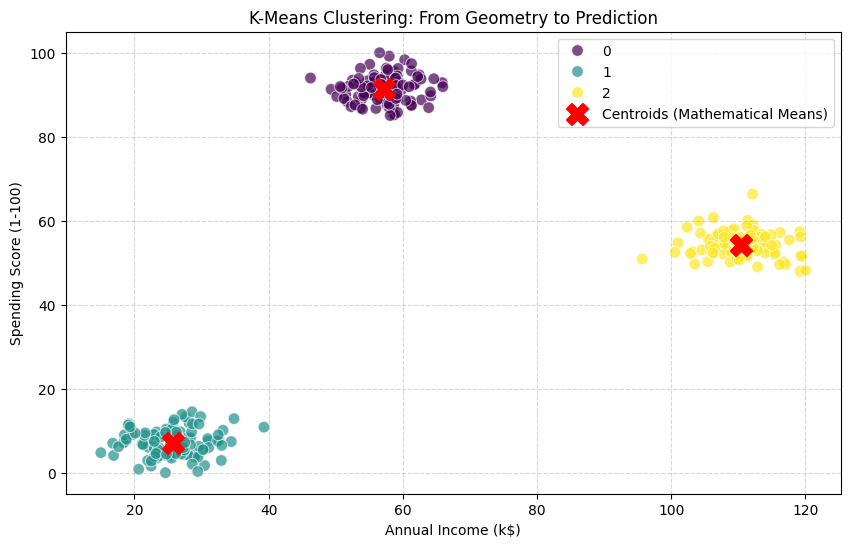

In [8]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_simulated, 
    x='Annual_Income', 
    y='Spending_Score', 
    hue='Cluster', 
    palette='viridis', 
    s=70, 
    alpha=0.7
)


centroids_original = scaler.inverse_transform(centroids)

plt.scatter(
    centroids_original[:, 0], 
    centroids_original[:, 1], 
    c='red', 
    marker='X', 
    s=250, 
    label='Centroids (Mathematical Means)'
)

plt.title('K-Means Clustering: From Geometry to Prediction')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Final Synthesis: From Geometry to Algorithmic Intelligence

### 1. The Mathematical Bridge
In this notebook, we successfully bridged the gap between abstract geometry and Python implementation. By defining the **Euclidean Distance** and the **WCSS** objective function, we established the mathematical criteria that our algorithm uses to minimize "geometric cost."

### 2. Why We Used Synthetic Data
The use of `make_blobs` allowed us to create a **"Ground Truth"** environment. Testing algorithms on controlled data is a critical validation step in Data Science. It proves that the logic works perfectly when the underlying clusters are known, providing a benchmark for the "messy" real-world data in the next stage.

### 3. Key Takeaways
* **Scaling is Mandatory:** Without normalization, distance-based clustering is biased.
* **Centroids as Profiles:** Each centroid represents the mathematical heart of a customer segment.
* **Convergence:** The algorithm successfully identified the 3 hidden groups we generated.

---
**Next Step:** We are now ready to apply these principles to the **Kaggle Credit Card Dataset** in **Notebook 2**, where we will deal with high-dimensional data and use **PCA** for dimensionality reduction.